In [9]:
import warnings
from pathlib import Path
import pickle

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    GridSearchCV,
    train_test_split
)

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [10]:
# Task 2: Load the dataset
file_path = Path('medical_insurance.csv')
df = pd.read_csv(file_path)
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [11]:
# Task 3: Inspect the dataset
print('Shape:', df.shape)
print('\nInfo:')
df.info()
print('\nDescribe:')
print(df.describe())
print('\nMissing values:')
print(df.isnull().sum())

Shape: (1338, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Describe:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750 

In [12]:
# Task 4: Detect and remove outliers using the IQR method
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
outlier_summary = {}
clean_df = df.copy()

for column in numeric_columns:
    q1 = clean_df[column].quantile(0.25)
    q3 = clean_df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (clean_df[column] < lower_bound) | (clean_df[column] > upper_bound)
    outlier_summary[column] = int(outlier_mask.sum())
    clean_df = clean_df.loc[~outlier_mask].copy()
    print(f'{column}: lower={lower_bound:.3f}, upper={upper_bound:.3f}, outliers={outlier_summary[column]}')

print('\nOriginal shape:', df.shape)
print('Cleaned shape:', clean_df.shape)
print('Outlier summary:', outlier_summary)

age: lower=-9.000, upper=87.000, outliers=0
bmi: lower=13.700, upper=47.290, outliers=9
children: lower=-3.000, upper=5.000, outliers=0
charges: lower=-13034.076, upper=34358.842, outliers=138

Original shape: (1338, 7)
Cleaned shape: (1191, 7)
Outlier summary: {'age': 0, 'bmi': 9, 'children': 0, 'charges': 138}


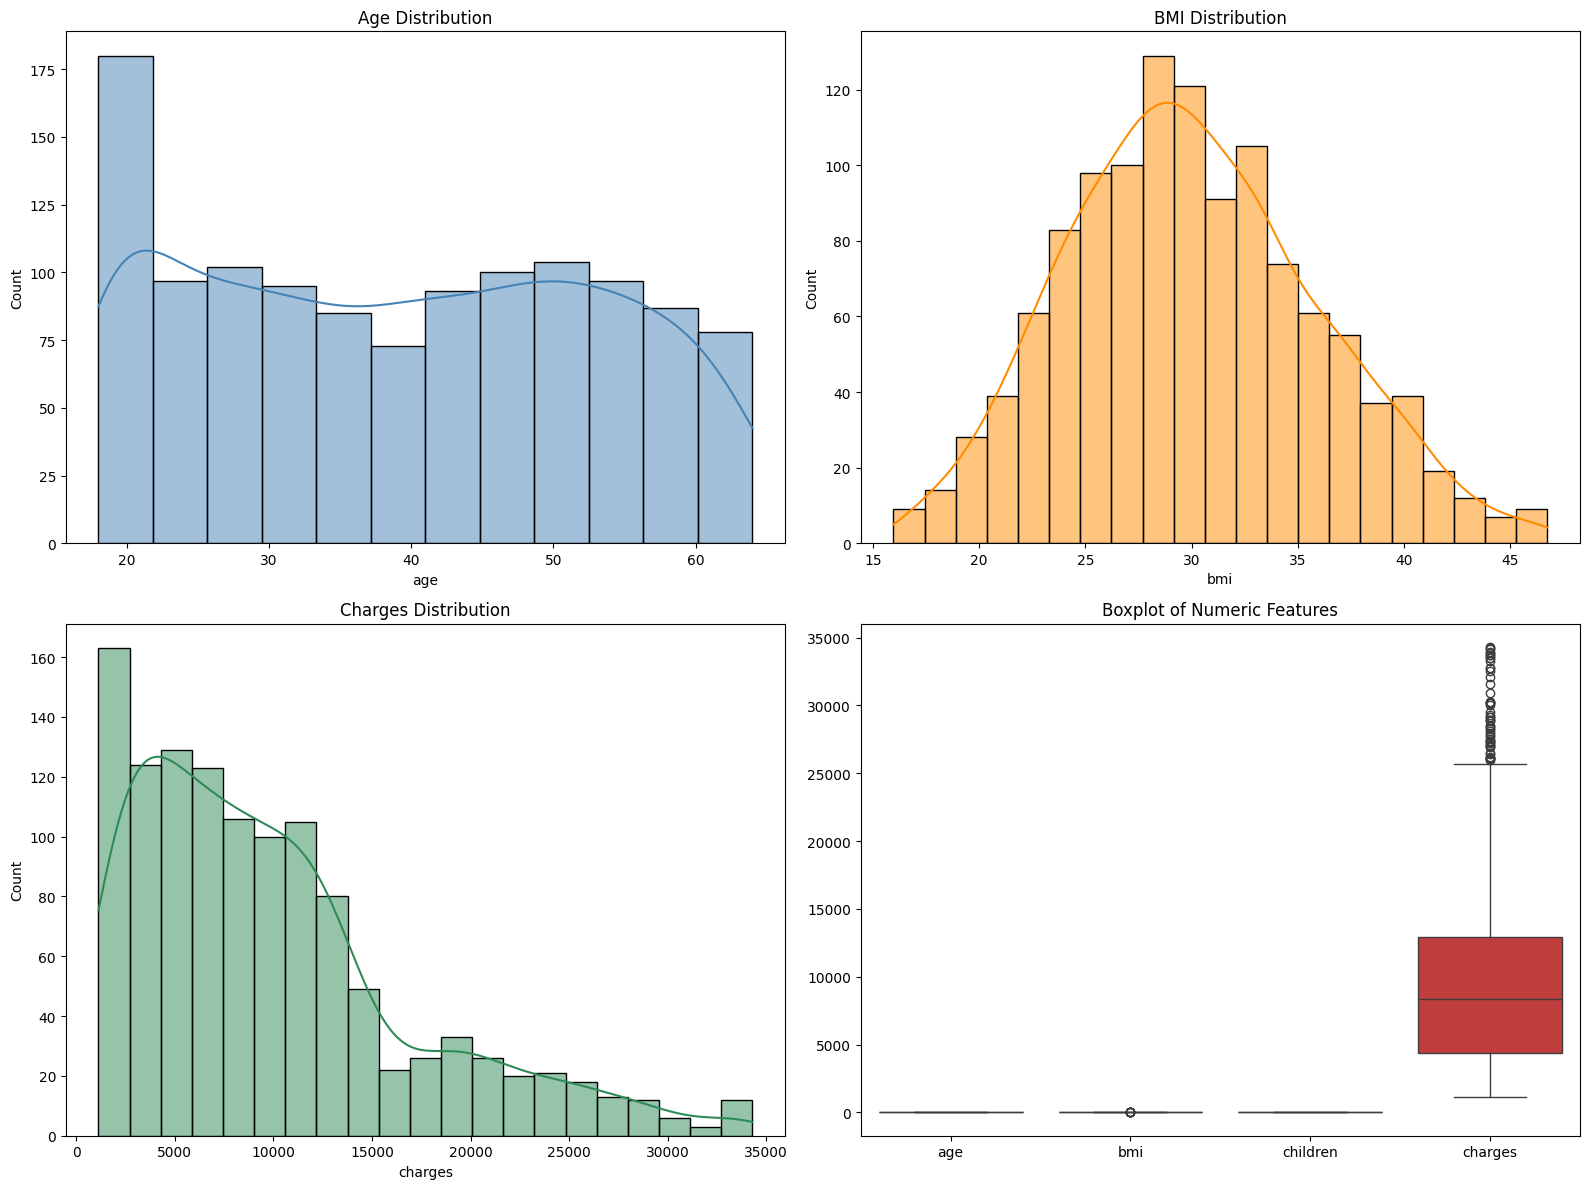

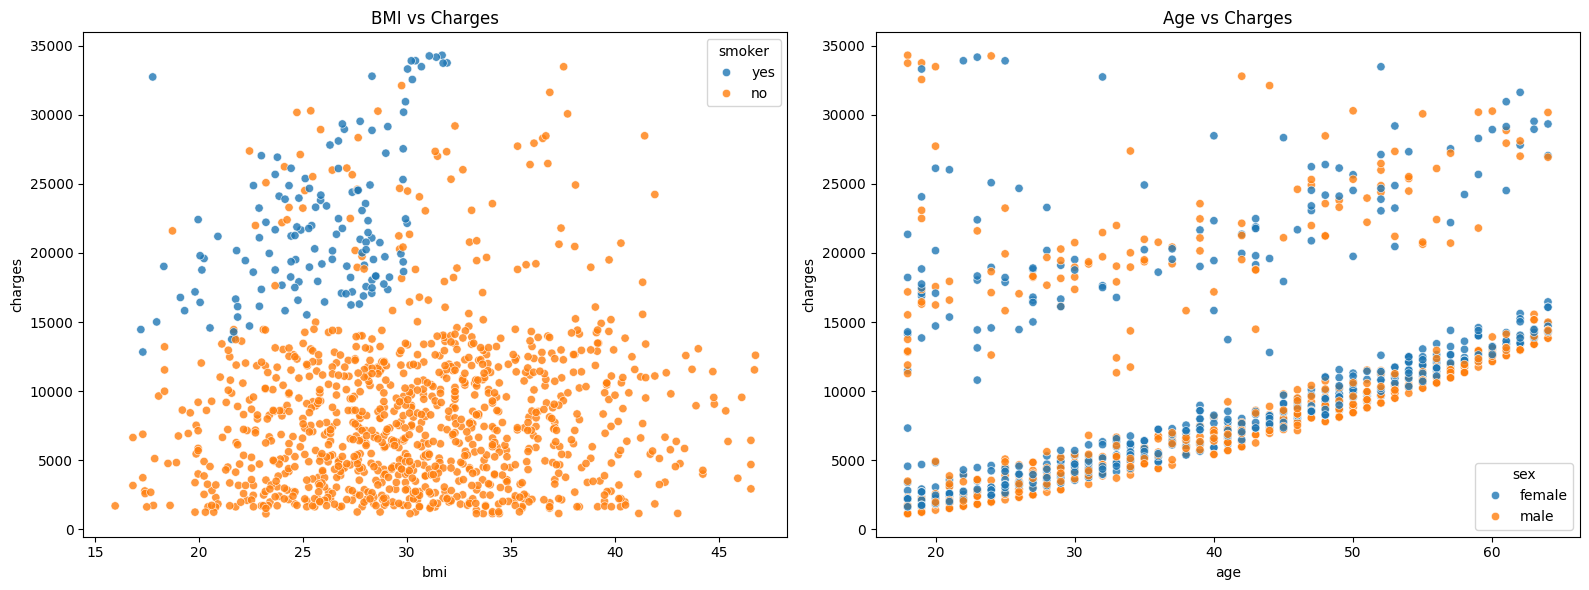

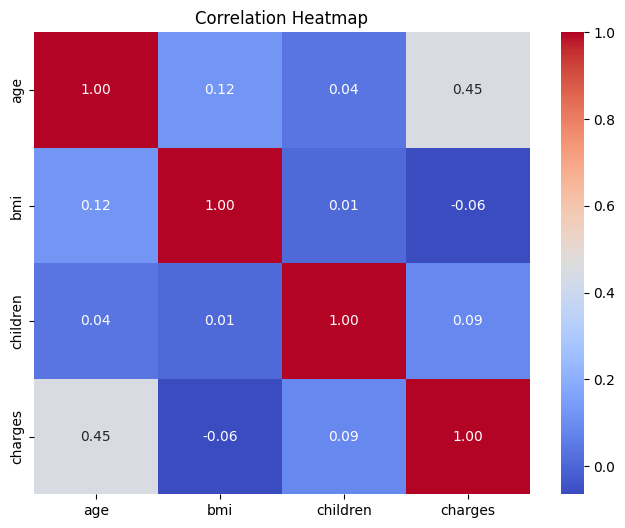

In [13]:
# Task 5: Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.histplot(clean_df['age'], kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Age Distribution')
sns.histplot(clean_df['bmi'], kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('BMI Distribution')
sns.histplot(clean_df['charges'], kde=True, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Charges Distribution')
sns.boxplot(data=clean_df[['age', 'bmi', 'children', 'charges']], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot of Numeric Features')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=clean_df, x='bmi', y='charges', hue='smoker', alpha=0.8, ax=axes[0])
axes[0].set_title('BMI vs Charges')
sns.scatterplot(data=clean_df, x='age', y='charges', hue='sex', alpha=0.8, ax=axes[1])
axes[1].set_title('Age vs Charges')
plt.tight_layout()
plt.show()

numeric_corr = clean_df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [14]:
# Task 6: Train-test split and preprocessing (pandas encoding + StandardScaler)
X = clean_df.drop('charges', axis=1)
y = clean_df['charges']

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

# One-hot encode categorical features using pandas
X_encoded = pd.get_dummies(X, drop_first=True)

# Split now to avoid leaking test information into the scaler
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Scale numeric features using StandardScaler
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

svr_model = SVR()

X_train.shape, X_test.shape

((952, 8), (239, 8))

In [15]:
# Task 7: Model selection with GridSearchCV
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [1, 10, 50],
    'epsilon': [0.1, 0.2, 0.5],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    estimator=svr_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print('Best Params:', grid_search.best_params_)
print('Best CV Score:', grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'C': 50, 'epsilon': 0.5, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score: 0.2727492321397187


Mean Squared Error: 33090010.96749864
Root Mean Squared Error: 5752.391760606943
Mean Absolute Error: 3022.036027374899
R2 Score: 0.38875187586219917


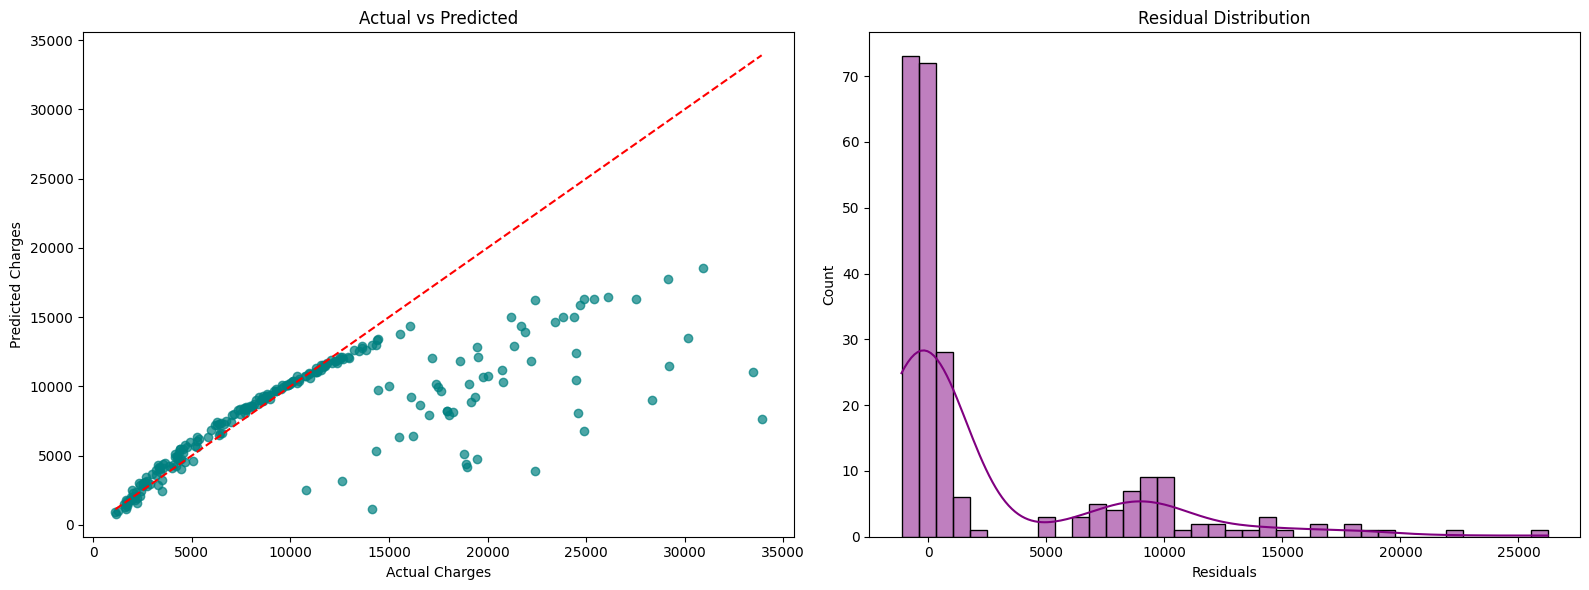

In [16]:
# Task 8: Evaluation metrics and residual plots
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('Mean Absolute Error:', mae)
print('R2 Score:', r2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(y_test, y_pred, alpha=0.7, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Actual vs Predicted')

residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residuals')
plt.tight_layout()
plt.show()

In [17]:
# Task 9: Export the trained model, scaler, and feature columns
artifact = {
    'model': best_model,
    'scaler': scaler,
    'feature_columns': X_train.columns.tolist()
}
joblib.dump(artifact, 'svm_insurance_artifact.joblib')
with open('svm_insurance_artifact.pkl', 'wb') as file:
    pickle.dump(artifact, file)

loaded_artifact = joblib.load('svm_insurance_artifact.joblib')
sample_prediction = loaded_artifact['model'].predict(X_test.iloc[:3])
print('Sample predictions:', sample_prediction)

Sample predictions: [10917.15267541  4810.08920359  9775.95030012]


In [18]:
import joblib

joblib.dump(model, "svm_insurance_model.joblib")

NameError: name 'model' is not defined